# MaskLayout Data Processing Guide

A comprehensive visualization of all data used in the MaskLayout project for masked floor plan generation.

**Dataset**: Swiss Dwelling (42,644 floorplans, tripled to 127,932 for training)  
**Modalities**: Dual-modal (Image tokens + Vector attributes)  
**Attributes**: T (Type), S (Size), L (Location), A (Adjacency), R (Room polygon), W (Windows)

## Section 1: Setup & Constants

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import json
import os
from collections import Counter

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

# --- Project Paths ---
MASKLAYOUT_DIR = os.path.dirname(os.path.abspath('__file__'))  # repo root
DATA_DIR = os.path.join(MASKLAYOUT_DIR, 'Data')

# --- Constants ---
max_room = 14
T_dim = 10        # one-hot type dimension: [0-7]=room types, [8]=end, [9]=start
L_dim = 7         # location bits (max 128)
S_dim = 6         # size/area bits (max 64)
R_num_10 = 10     # corner points (old)
R_num_20 = 20     # corner points (new)
img_res = 128     # image resolution

# --- Color Palette (pre-defined per room type) ---
# T_dim structure: indices 0-7 = 8 room types, index 8 = end token, index 9 = start token
# Room type order (0-7): LivingRoom, Bathroom, Closet, Bedroom, Kitchen, Dining, Balcony, Corridor
color_list_rgb = [
    [0/255, 255/255, 255/255],      # 0: LivingRoom   (0, 255, 255)
    [255/255, 255/255, 0/255],      # 1: Bathroom     (255, 255, 0)
    [0/255, 0/255, 255/255],        # 2: Closet       (0, 0, 255)
    [255/255, 0/255, 255/255],      # 3: Bedroom      (255, 0, 255)
    [255/255, 127/255, 127/255],    # 4: Kitchen      (255, 127, 127)
    [0/255, 255/255, 0/255],        # 5: Dining       (0, 255, 0)
    [127/255, 255/255, 127/255],    # 6: Balcony      (127, 255, 127)
    [127/255, 127/255, 255/255],    # 7: Corridor     (127, 127, 255)
    [0.5, 0.5, 0.5],               # 8: End Token (not displayed)
    [0, 0, 0],                     # 9: Start Token (not displayed)
]

Types_List = ['LivingRoom', 'Bathroom', 'Closet', 'Bedroom', 'Kitchen', 'Dining', 'Balcony', 'Corridor', 'End', 'Start']
attribute_list = ['T', 'S', 'L', 'A', 'R', 'W']

# --- Helper Functions ---
def bit2int(b, bits):
    """Convert binary bit array to integer (numpy version)."""
    mask = 2 ** np.arange(bits - 1, -1, -1)
    return np.sum(mask * b, axis=-1)

def make_bit(value, dimension):
    """Convert integer to binary bit array."""
    return np.array(list(np.binary_repr(int(value)).zfill(dimension))).astype(np.int32)

def print_array_info(name, arr):
    """Print shape, dtype, and basic stats for a numpy array."""
    print(f"  {name:30s} | shape: {str(arr.shape):25s} | dtype: {str(arr.dtype):10s} | "
          f"min: {arr.min():8.3f} | max: {arr.max():8.3f} | mean: {arr.mean():8.3f}")

print('Setup complete.')
print(f'MaskLayout dir: {MASKLAYOUT_DIR}')
print(f'Data dir: {DATA_DIR}')

Setup complete.
MaskLayout dir: /Users/hang/Documents/GitHub/MaskLayout
Data dir: /Users/hang/Documents/GitHub/MaskLayout/Data


## Section 2: Room Type Taxonomy

The Swiss Dwelling dataset contains 74 raw room subtypes. For the MaskLayout model, these are mapped to **8 residential room categories** (indexed 1-8). The `house` column in `room_type.csv` defines this mapping.

In [107]:
# Load room type taxonomy
room_type_csv = os.path.join(MASKLAYOUT_DIR, 'Data_Process', 'room_type.csv')
try:
    df_room = pd.read_csv(room_type_csv)
    print(f'Loaded room_type.csv: {df_room.shape[0]} raw room subtypes')
    print(f'Columns: {list(df_room.columns)}\n')
    display(df_room)
except Exception as e:
    print(f'Error loading room_type.csv: {e}')

Loaded room_type.csv: 73 raw room subtypes
Columns: ['entity_subtype', 'publicspace', 'house', 'COMMERCIAL', 'PUBLIC', 'RESIDENTIAL', 'JANITOR', 'room']



,entity_subtype,publicspace,house,COMMERCIAL,PUBLIC,RESIDENTIAL,JANITOR,room
0,AIR,0.0,0,0,1,0,0,0
1,ARCHIVE,0.0,0,1,1,0,0,1
2,BALCONY,0.0,7,1,1,1,0,1
3,BASEMENT,1.0,0,0,1,0,0,1
4,BASEMENT_COMPARTMENT,1.0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...
68,WAREHOUSE,1.0,0,1,1,0,0,1
69,WASH_AND_DRY_ROOM,1.0,0,0,1,0,0,1
70,WATER_SUPPLY,0.0,0,0,1,0,0,1
71,WINTERGARTEN,1.0,0,0,1,1,0,1


=== 74 Raw Types -> 8 Category Mapping ===
  1 (LivingRoom): LIVING_DINING, LIVING_ROOM
  2 (  Bathroom): BATHROOM
  3 (    Closet): STOREROOM
  4 (   Bedroom): BEDROOM, ROOM, STUDIO, VOID
  5 (   Kitchen): KITCHEN, KITCHEN_DINING
  6 (    Dining): DINING
  7 (   Balcony): BALCONY, LOGGIA, TERRACE
  8 (  Corridor): CORRIDOR, CORRIDORS_AND_HALLS
  0 (  Unmapped): 57 types (public/technical spaces)


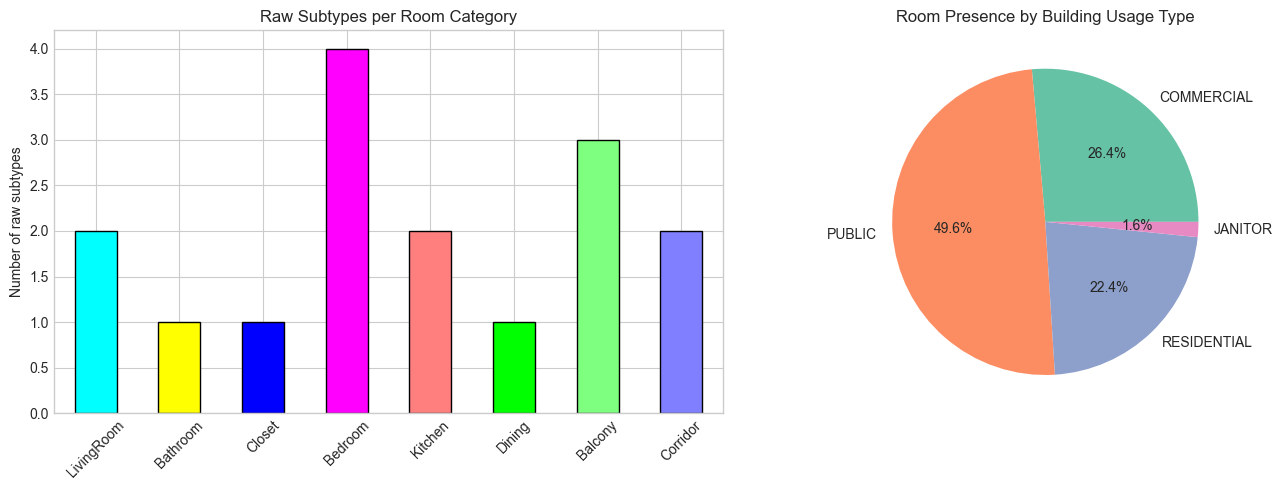

In [108]:
# --- Room Category Mapping ---
# Matches T_dim indices 0-7
house_mapping = {0: 'Unmapped', 1: 'LivingRoom', 2: 'Bathroom', 3: 'Closet',
                 4: 'Bedroom', 5: 'Kitchen', 6: 'Dining', 7: 'Balcony', 8: 'Corridor'}

df_room['house_cat'] = df_room['house'].map(house_mapping)

# Show which raw types map to each category
print('=== 74 Raw Types -> 8 Category Mapping ===')
for cat_id in range(1, 9):
    subtypes = df_room[df_room['house'] == cat_id]['entity_subtype'].tolist()
    print(f"  {cat_id} ({house_mapping[cat_id]:>10s}): {', '.join(subtypes)}")
unmapped = df_room[df_room['house'] == 0]['entity_subtype'].tolist()
print(f"  0 ({'Unmapped':>10s}): {len(unmapped)} types (public/technical spaces)")

# --- Bar chart: category counts ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df_room[df_room['house'] > 0].groupby('house_cat').size().reindex(
    [house_mapping[i] for i in range(1, 9)], fill_value=0)
colors = [color_list_rgb[i] for i in range(8)]
cat_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Raw Subtypes per Room Category')
axes[0].set_ylabel('Number of raw subtypes')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# --- Pie chart: building usage types ---
usage_cols = ['COMMERCIAL', 'PUBLIC', 'RESIDENTIAL', 'JANITOR']
usage_counts = df_room[usage_cols].sum()
axes[1].pie(usage_counts, labels=usage_cols, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(usage_cols)))
axes[1].set_title('Room Presence by Building Usage Type')

plt.tight_layout()
plt.show()

## Section 3: Base Vector Data

The core dataset is stored in `Data/sqe/swissD_Dual_Modal.npz` with 6 attributes:
- **T** (Type): One-hot encoded room types
- **S** (Size): Room area as binary bits
- **L** (Location): Room center (x, y) as binary bits
- **A** (Adjacency): Room adjacency matrix
- **R** (Region): Room polygon corner coordinates
- **W** (Window): Window locations

In [109]:
# Load base vector data
dual_modal_path = os.path.join(DATA_DIR, 'sqe', 'swissD_Dual_Modal.npz')
try:
    dm = np.load(dual_modal_path)
    print(f'Loaded swissD_Dual_Modal.npz')
    print(f'Keys: {list(dm.keys())}\n')
    for key in dm.keys():
        print_array_info(key, dm[key])
    
    T_data = dm['T']  # (N, max_room+2, T_dim)
    S_data = dm['S']  # (N, max_room+2, S_dim)
    L_data = dm['L']  # (N, max_room+2, 2, L_dim)
    A_data = dm['A']  # (N, max_room+2, max_room)
    R_data = dm['R']  # (N, max_room+2, R_num, 2, L_dim)
    W_data = dm['W']  # (N, W_num+2, 2, L_dim)
    N_plans = T_data.shape[0]
    print(f'\nTotal floor plans: {N_plans}')
except Exception as e:
    print(f'Error loading swissD_Dual_Modal.npz: {e}')
    T_data = S_data = L_data = A_data = R_data = W_data = None
    N_plans = 0

Loaded swissD_Dual_Modal.npz
Keys: ['T', 'L', 'A', 'S', 'R', 'W']

  T                              | shape: (42644, 16, 10)           | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.060
  L                              | shape: (42644, 16, 2, 7)         | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.351
  A                              | shape: (42644, 16, 14)           | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.204
  S                              | shape: (42644, 16, 6)            | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.287
  R                              | shape: (42644, 16, 20, 2, 7)     | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.226
  W                              | shape: (42644, 16, 2, 7)         | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.261

Total floor plans: 42644


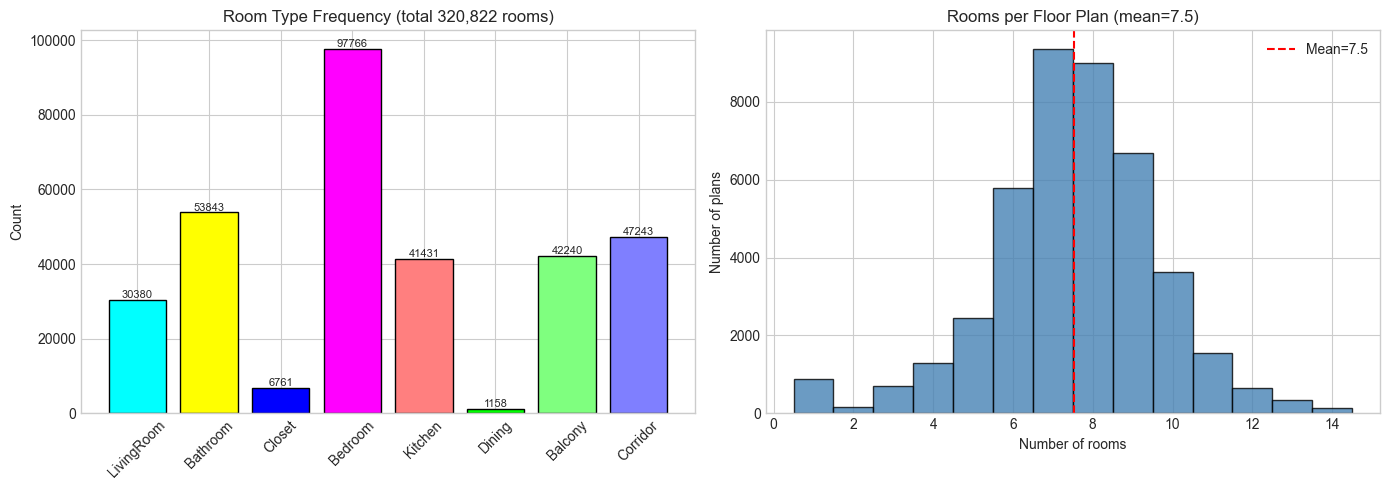


Rooms per plan distribution:
   1 rooms:    879 plans (2.1%)
   2 rooms:    150 plans (0.4%)
   3 rooms:    693 plans (1.6%)
   4 rooms:  1,299 plans (3.0%)
   5 rooms:  2,441 plans (5.7%)
   6 rooms:  5,801 plans (13.6%)
   7 rooms:  9,369 plans (22.0%)
   8 rooms:  9,005 plans (21.1%)
   9 rooms:  6,696 plans (15.7%)
  10 rooms:  3,642 plans (8.5%)
  11 rooms:  1,560 plans (3.7%)
  12 rooms:    651 plans (1.5%)
  13 rooms:    334 plans (0.8%)
  14 rooms:    124 plans (0.3%)


In [110]:
# --- T: Room Type Analysis ---
if T_data is not None:
    # T_data shape: (N, 16, 10)
    # Room slot dim: slot 0 = start token, slots 1-14 = rooms, slot 15 = end token
    # T_dim (one-hot): indices 0-7 = room types, index 8 = end token, index 9 = start token
    # Empty/padding rooms have all-zero vectors [0,0,0,0,0,0,0,0,0,0]
    T_indices = np.argmax(T_data[:, 1:-1, :], axis=-1)  # (N, 14)
    # Detect empty rooms: all-zero one-hot vectors (np.argmax returns 0 for these, same as LivingRoom)
    T_room_slots = T_data[:, 1:-1, :]  # (N, 14, 10)
    empty_mask = T_room_slots.sum(axis=-1) == 0  # (N, 14) - True where room slot is empty/padding
    # A room is valid if its type is between 0 and 7 AND it's not an empty slot
    valid_mask = (T_indices < 8) & (~empty_mask)
    valid_types = T_indices[valid_mask]
    
    # Rooms per plan
    rooms_per_plan = valid_mask.sum(axis=1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Type frequency bar chart
    type_counts = Counter(valid_types)
    type_names = [Types_List[i] for i in range(8)]
    type_vals = [type_counts.get(i, 0) for i in range(8)]
    colors = [color_list_rgb[i] for i in range(8)]
    axes[0].bar(type_names, type_vals, color=colors, edgecolor='black')
    axes[0].set_title(f'Room Type Frequency (total {sum(type_vals):,} rooms)')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(type_vals):
        axes[0].text(i, v + 500, str(v), ha='center', fontsize=8)
    
    # Rooms per plan histogram
    axes[1].hist(rooms_per_plan, bins=range(1, max_room + 2), color='steelblue',
                 edgecolor='black', alpha=0.8, align='left')
    axes[1].set_title(f'Rooms per Floor Plan (mean={rooms_per_plan.mean():.1f})')
    axes[1].set_xlabel('Number of rooms')
    axes[1].set_ylabel('Number of plans')
    axes[1].axvline(rooms_per_plan.mean(), color='red', linestyle='--', label=f'Mean={rooms_per_plan.mean():.1f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f'\nRooms per plan distribution:')
    for rc in sorted(np.unique(rooms_per_plan)):
        cnt = (rooms_per_plan == rc).sum()
        print(f'  {rc:2d} rooms: {cnt:6,} plans ({cnt/N_plans*100:.1f}%)')

/Users/hang/.codex_tmp/ipykernel_3688/3010407575.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([size_by_type[Types_List[t]] for t in range(8)],


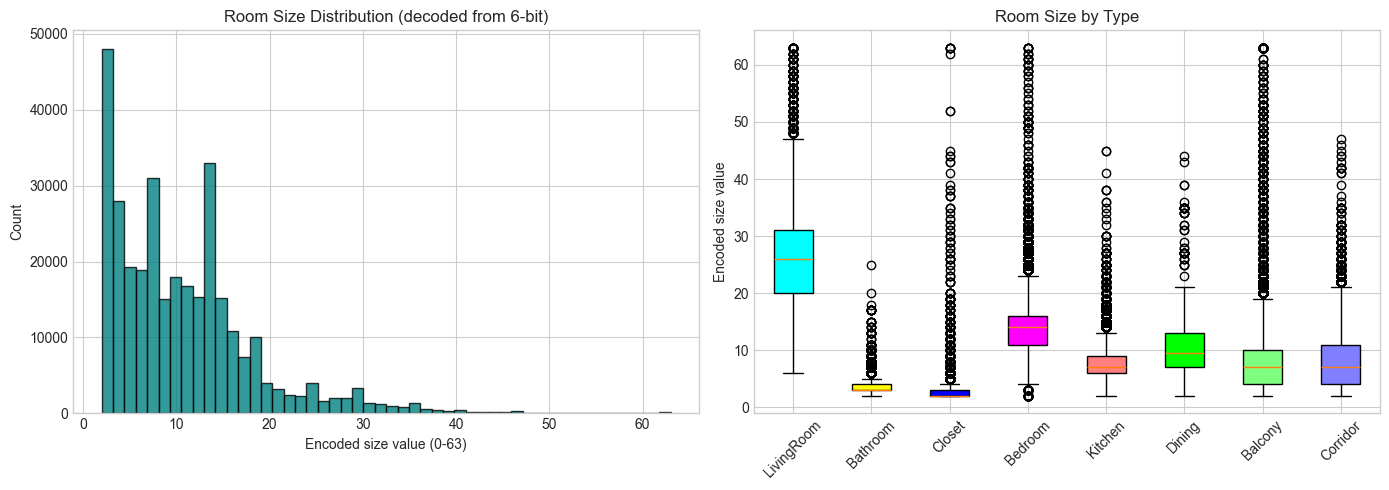

In [111]:
# --- S: Size/Area Analysis ---
if S_data is not None:
    # Decode binary bits to integer sizes
    S_int = bit2int(S_data[:, 1:-1, :], S_dim)  # (N, 14)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Overall size histogram
    valid_sizes = S_int[valid_mask]
    axes[0].hist(valid_sizes, bins=50, color='teal', edgecolor='black', alpha=0.8)
    axes[0].set_title(f'Room Size Distribution (decoded from {S_dim}-bit)')
    axes[0].set_xlabel('Encoded size value (0-63)')
    axes[0].set_ylabel('Count')
    
    # Size by room type (box plot)
    size_by_type = {Types_List[t]: S_int[(T_indices == t) & valid_mask] 
                    for t in range(8)}
    bp = axes[1].boxplot([size_by_type[Types_List[t]] for t in range(8)],
                         labels=[Types_List[t] for t in range(8)],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], [color_list_rgb[i] for i in range(8)]):
        patch.set_facecolor(color)
    axes[1].set_title('Room Size by Type')
    axes[1].set_ylabel('Encoded size value')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

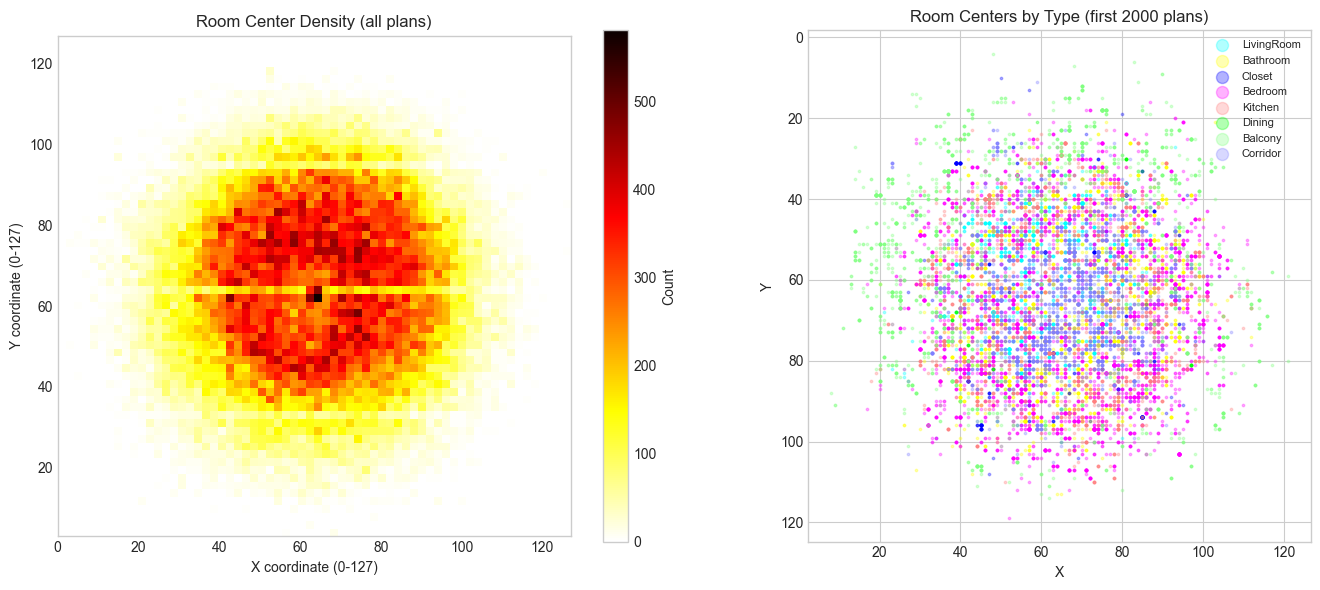

In [112]:
# --- L: Location Analysis ---
if L_data is not None:
    # L_data: (N, max_room+2, 2, L_dim)
    # Same L_dim (7-bit) representation as W_data
    # Slot 0 = start token: [[1,1,1,1,1,1,1],[1,1,1,1,1,1,1]] (decodes to [127,127])
    # Slot -1 = end token:  [[1,1,1,1,1,1,0],[1,1,1,1,1,1,0]] (decodes to [126,126])
    # Slots 1:-1 = actual room center locations
    # Decode binary bits to (x, y) coordinates
    L_xy = bit2int(L_data[:, 1:-1, :, :], L_dim)  # (N, 14, 2)
    L_x = L_xy[:, :, 0][valid_mask]  # valid room x-coords
    L_y = L_xy[:, :, 1][valid_mask]  # valid room y-coords
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 2D density heatmap of room centers
    h = axes[0].hist2d(L_x, L_y, bins=64, cmap='hot_r')
    plt.colorbar(h[3], ax=axes[0], label='Count')
    axes[0].set_title('Room Center Density (all plans)')
    axes[0].set_xlabel('X coordinate (0-127)')
    axes[0].set_ylabel('Y coordinate (0-127)')
    axes[0].set_aspect('equal')
    
    # Location by room type scatter (sample)
    sample_n = min(2000, N_plans)
    for t in range(8):
        t_mask = (T_indices[:sample_n] == t) & valid_mask[:sample_n]
        lx = L_xy[:sample_n, :, 0][t_mask]
        ly = L_xy[:sample_n, :, 1][t_mask]
        axes[1].scatter(lx, ly, c=[color_list_rgb[t]], s=3, alpha=0.3, label=Types_List[t])
    axes[1].set_title(f'Room Centers by Type (first {sample_n} plans)')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].legend(markerscale=5, fontsize=8)
    axes[1].set_aspect('equal')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

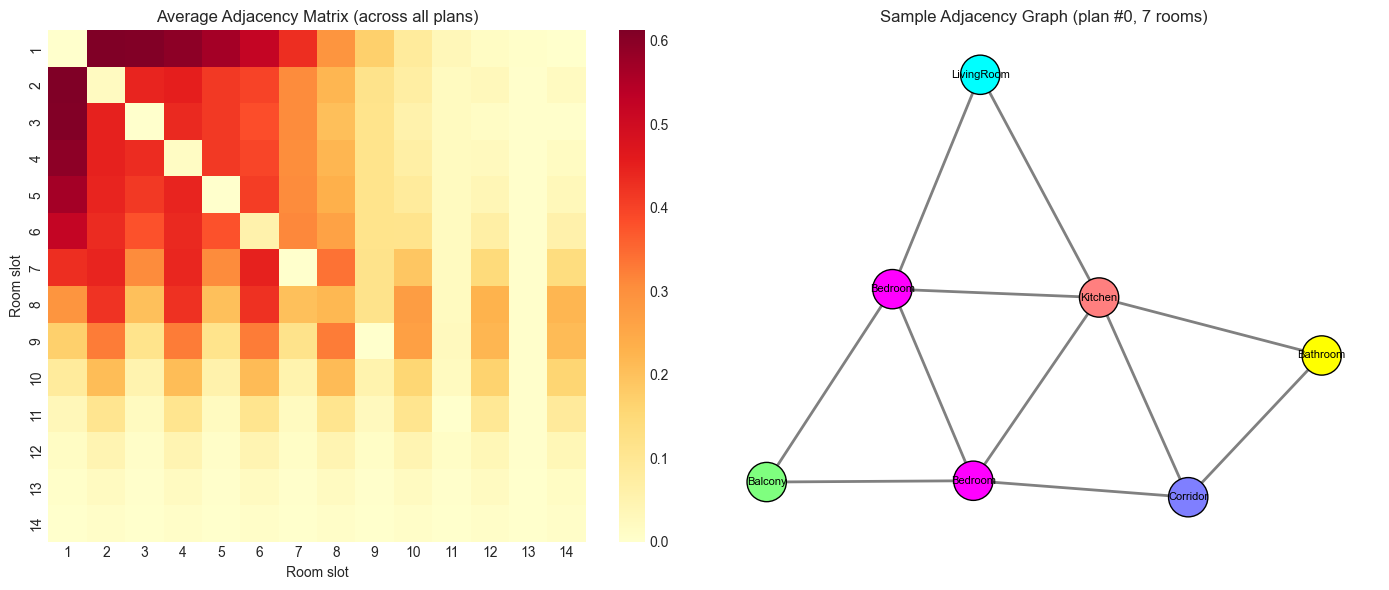

In [113]:
# --- A: Adjacency Matrix Analysis ---
if A_data is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Average adjacency matrix across all plans
    A_rooms = A_data[:, 1:-1, :]  # (N, 14, 14)
    avg_adj = A_rooms.mean(axis=0)
    sns.heatmap(avg_adj, ax=axes[0], cmap='YlOrRd', annot=False,
                xticklabels=range(1, max_room + 1),
                yticklabels=range(1, max_room + 1))
    axes[0].set_title('Average Adjacency Matrix (across all plans)')
    axes[0].set_xlabel('Room slot')
    axes[0].set_ylabel('Room slot')
    
    # Sample adjacency graph with networkx
    try:
        import networkx as nx
        # Pick a plan - try common room counts, fallback to first plan
        sample_idx = None
        for target in [7, 8, 6, 5, 9, 4]:
            candidates = np.where(rooms_per_plan == target)[0]
            if len(candidates) > 0:
                sample_idx = candidates[0]
                break
        if sample_idx is None:
            sample_idx = 0
        
        adj_sample = A_rooms[sample_idx]
        n_rooms = rooms_per_plan[sample_idx]
        types_sample = T_indices[sample_idx]
        
        G = nx.Graph()
        for i in range(n_rooms):
            G.add_node(i, label=Types_List[types_sample[i]])
        for i in range(n_rooms):
            for j in range(i + 1, n_rooms):
                if adj_sample[i, j] > 0.5:
                    G.add_edge(i, j)
        
        node_colors = [color_list_rgb[types_sample[i]] for i in range(n_rooms)]
        labels = {i: Types_List[types_sample[i]] for i in range(n_rooms)}
        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, ax=axes[1], node_color=node_colors, labels=labels,
                with_labels=True, node_size=800, font_size=8, edgecolors='black',
                edge_color='gray', width=2)
        axes[1].set_title(f'Sample Adjacency Graph (plan #{sample_idx}, {n_rooms} rooms)')
    except ImportError:
        axes[1].text(0.5, 0.5, 'networkx not installed', ha='center', va='center',
                     transform=axes[1].transAxes)
    
    plt.tight_layout()
    plt.show()

R_data shape: (42644, 16, 20, 2, 7) -> R_num = 20


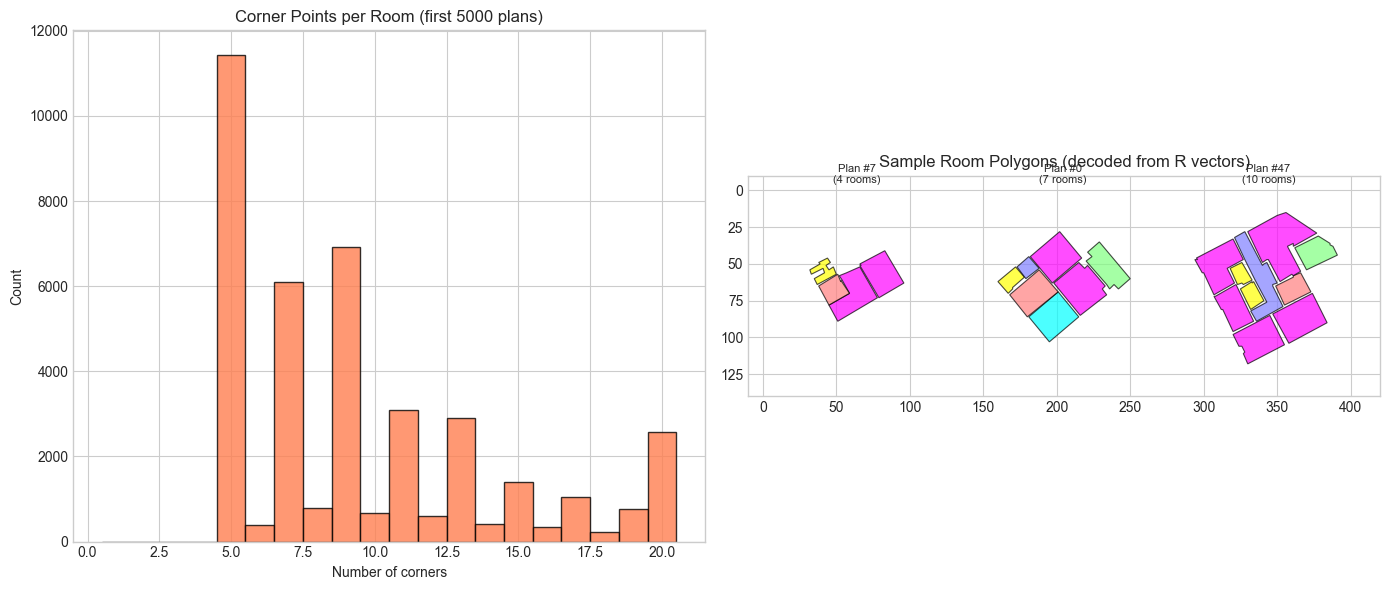

In [101]:
# --- R: Room Polygon (Region) Analysis ---
if R_data is not None:
    R_num = R_data.shape[2]  # actual R_num from data
    print(f'R_data shape: {R_data.shape} -> R_num = {R_num}')
    
    # Decode corner coordinates
    R_corners = bit2int(R_data[:, 1:-1, :, :, :], L_dim)  # (N, 14, R_num, 2)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Corner count distribution (non-zero corners per room)
    sample_n = min(5000, N_plans)
    corner_counts = []
    for p in range(sample_n):
        for r in range(max_room):
            if valid_mask[p, r]:
                corners = R_corners[p, r]  # (R_num, 2)
                non_zero = np.any(corners != 0, axis=1).sum()
                if non_zero > 0:
                    corner_counts.append(non_zero)
    
    axes[0].hist(corner_counts, bins=range(1, R_num + 2), color='coral',
                 edgecolor='black', alpha=0.8, align='left')
    axes[0].set_title(f'Corner Points per Room (first {sample_n} plans)')
    axes[0].set_xlabel('Number of corners')
    axes[0].set_ylabel('Count')
    
    # Sample polygon visualizations (3 plans with different room counts)
    sample_plans = []
    for target in [4, 7, 10, 6, 8, 5, 9, 3, 11, 12]:
        idx = np.where(rooms_per_plan == target)[0]
        if len(idx) > 0 and len(sample_plans) < 3:
            sample_plans.append(idx[0])
    if not sample_plans:
        sample_plans = list(range(min(3, N_plans)))
    
    ax_poly = axes[1]
    for si, pidx in enumerate(sample_plans[:3]):
        n_r = rooms_per_plan[pidx]
        for r in range(n_r):
            corners = R_corners[pidx, r]
            non_zero_mask = np.any(corners != 0, axis=1)
            pts = corners[non_zero_mask]
            if len(pts) >= 3:
                # Offset each plan horizontally
                pts_shifted = pts.copy().astype(float)
                pts_shifted[:, 0] += si * 140
                polygon = plt.Polygon(pts_shifted, closed=True,
                                       facecolor=color_list_rgb[T_indices[pidx, r]],
                                       edgecolor='black', linewidth=0.8, alpha=0.7)
                ax_poly.add_patch(polygon)
        ax_poly.text(si * 140 + 64, -5, f'Plan #{pidx}\n({n_r} rooms)',
                     ha='center', fontsize=8)
    ax_poly.set_xlim(-10, len(sample_plans) * 140)
    ax_poly.set_ylim(-10, 140)
    ax_poly.set_aspect('equal')
    ax_poly.invert_yaxis()
    ax_poly.set_title('Sample Room Polygons (decoded from R vectors)')
    
    plt.tight_layout()
    plt.show()

W_data shape: (42644, 16, 2, 7)


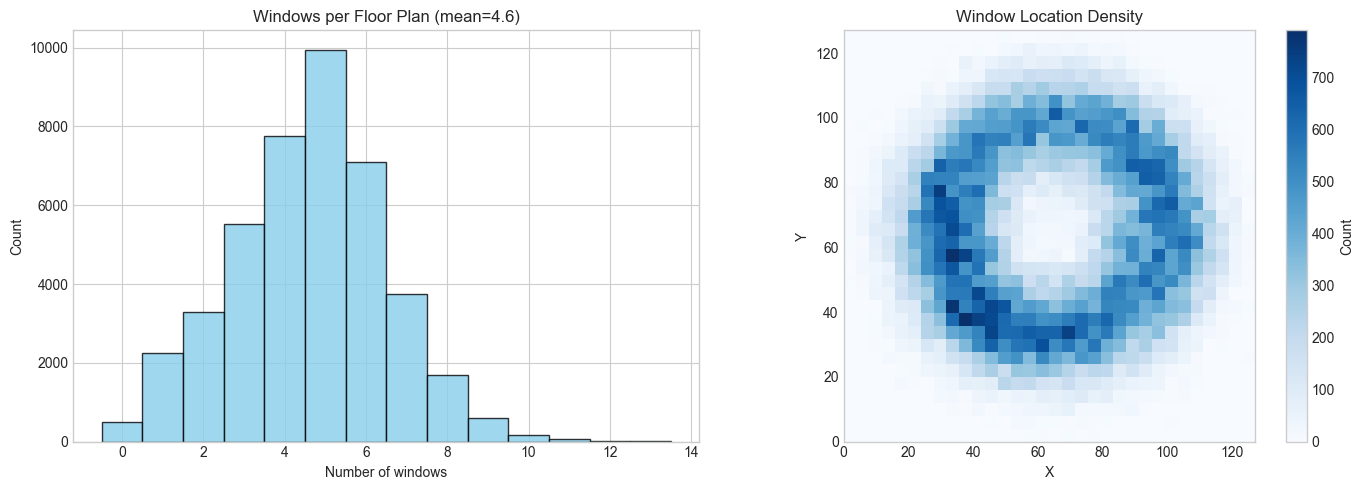

In [114]:
# --- W: Window Analysis ---
if W_data is not None:
    print(f'W_data shape: {W_data.shape}')
    # W_data: (N, W_num+2, 2, L_dim)
    # Slot 0 = start token: [[1,1,1,1,1,1,1],[1,1,1,1,1,1,1]] (decodes to [127,127])
    # Slot -1 = end token:  [[1,1,1,1,1,1,0],[1,1,1,1,1,1,0]] (decodes to [126,126])
    # Slots 1:-1 = actual window positions
    W_decoded = bit2int(W_data[:, 1:-1, :, :], L_dim)  # decode window locations

    # Filter out start token [127,127] and end token [126,126] values
    W_is_start = (W_decoded[:, :, 0] == 127) & (W_decoded[:, :, 1] == 127)
    W_is_end = (W_decoded[:, :, 0] == 126) & (W_decoded[:, :, 1] == 126)
    # Window is valid if non-zero and not a start/end token value
    W_nonzero = np.any(W_decoded != 0, axis=-1)  # (N, W_slots)
    W_valid = W_nonzero & (~W_is_start) & (~W_is_end)
    windows_per_plan = W_valid.sum(axis=1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(windows_per_plan, bins=range(0, int(windows_per_plan.max()) + 2),
                 color='skyblue', edgecolor='black', alpha=0.8, align='left')
    axes[0].set_title(f'Windows per Floor Plan (mean={windows_per_plan.mean():.1f})')
    axes[0].set_xlabel('Number of windows')
    axes[0].set_ylabel('Count')
    
    # Window location density
    W_x = W_decoded[:, :, 0][W_valid]
    W_y = W_decoded[:, :, 1][W_valid]
    h = axes[1].hist2d(W_x, W_y, bins=32, cmap='Blues')
    plt.colorbar(h[3], ax=axes[1], label='Count')
    axes[1].set_title('Window Location Density')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

In [115]:
# --- Also load new_R_10.npy (older 10-corner version) ---
new_R_path = os.path.join(DATA_DIR, 'sqe', 'new_R_10.npy')
try:
    new_R_10 = np.load(new_R_path)
    print(f'new_R_10.npy:')
    print_array_info('new_R_10', new_R_10)
    print(f'  This is the older version with R_num=10 corner points per room.')
except Exception as e:
    print(f'Could not load new_R_10.npy: {e}')

new_R_10.npy:
  new_R_10                       | shape: (42644, 16, 10, 2, 7)     | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.237
  This is the older version with R_num=10 corner points per room.


## Section 4: Image-Token Data

The masked training uses **complete** and **partial** image token representations. These are VQ-VAE codebook indices organized per attribute and room.

In [116]:
# Load image mask data
img_complete_path = os.path.join(DATA_DIR, 'img_mask_complete_3.npz')
img_partial_path = os.path.join(DATA_DIR, 'img_mask_partial_3.npz')

try:
    img_complete = np.load(img_complete_path)
    img_partial = np.load(img_partial_path)
    print('=== img_mask_complete_3.npz ===')
    for key in img_complete.keys():
        print_array_info(key, img_complete[key])
    print('\n=== img_mask_partial_3.npz ===')
    for key in img_partial.keys():
        print_array_info(key, img_partial[key])
except Exception as e:
    print(f'Error loading image mask data: {e}')
    img_complete = img_partial = None

=== img_mask_complete_3.npz ===
  T                              | shape: (127932, 14, 16)          | dtype: uint8      | min:    0.000 | max:   31.000 | mean:    6.037
  S                              | shape: (127932, 14, 16)          | dtype: uint8      | min:    0.000 | max:   31.000 | mean:    9.666
  L                              | shape: (127932, 14, 16)          | dtype: uint8      | min:    0.000 | max:   31.000 | mean:    7.740
  A                              | shape: (127932, 14, 16)          | dtype: uint8      | min:    0.000 | max:   31.000 | mean:    8.331
  R                              | shape: (127932, 14, 16)          | dtype: uint8      | min:    0.000 | max:   31.000 | mean:    7.391
  W                              | shape: (127932, 14, 16)          | dtype: uint8      | min:    0.000 | max:   31.000 | mean:    4.451

=== img_mask_partial_3.npz ===
  T                              | shape: (127932, 14, 25)          | dtype: uint8      | min:    0.000 | max:   3

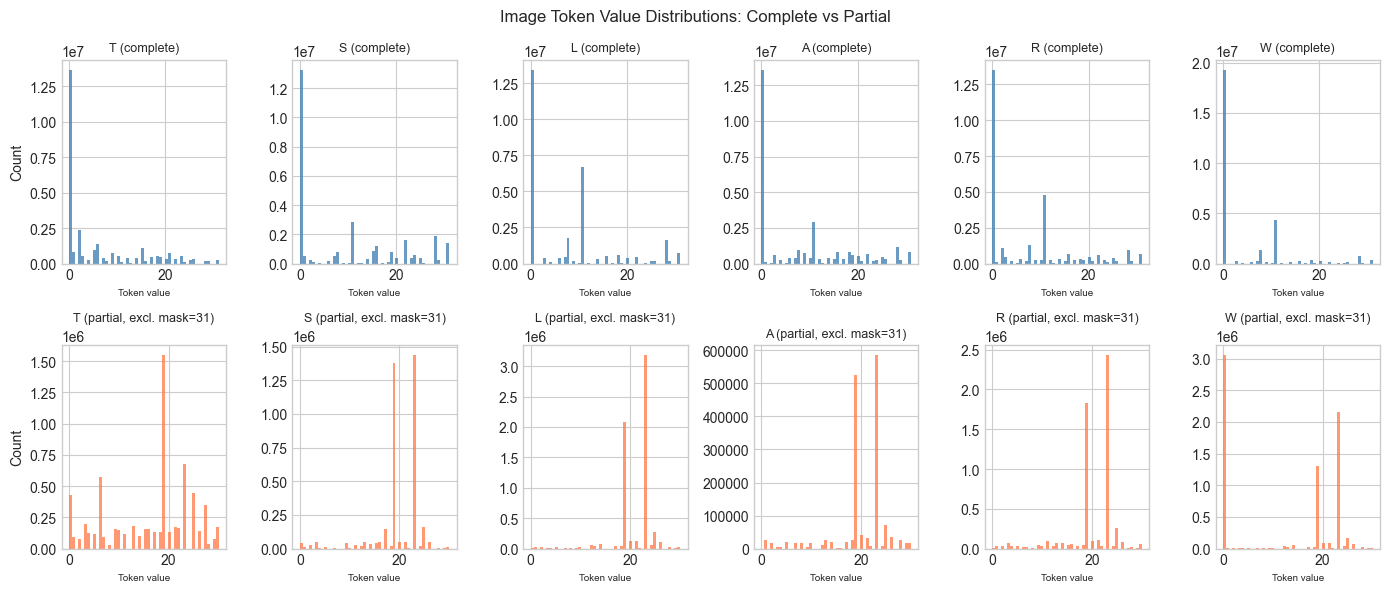


=== Masking Ratio Statistics ===
  T: 32.1% masked (28,656,768 total -> 37,866,881 masked tokens, 6,909,319 valid tokens)
  S: 43.1% masked (28,656,768 total -> 41,017,638 masked tokens, 3,758,562 valid tokens)
  L: 33.8% masked (28,656,768 total -> 38,352,900 masked tokens, 6,423,300 valid tokens)
  A: 50.7% masked (28,656,768 total -> 43,173,332 masked tokens, 1,602,868 valid tokens)
  R: 36.2% masked (28,656,768 total -> 39,038,569 masked tokens, 5,737,631 valid tokens)
  W: 30.8% masked (28,656,768 total -> 37,487,300 masked tokens, 7,288,900 valid tokens)


In [119]:
if img_complete is not None and img_partial is not None:
    # In img_mask_partial_3.npz, all 25 tokens with value 31 indicates a masked image (room fully masked)
    # Token value 0 is a valid codebook index — do NOT filter it out
    MASK_TOKEN = 31
    keys_c = list(img_complete.keys())
    n_attrs = len(keys_c)
    
    fig, axes = plt.subplots(2, min(n_attrs, 6), figsize=(14, 6))
    if n_attrs == 1:
        axes = axes.reshape(-1, 1)
    
    for i, key in enumerate(keys_c[:6]):
        # Complete token histogram (all values are valid)
        vals_c = img_complete[key].flatten()
        axes[0, i].hist(vals_c, bins=50, color='steelblue', alpha=0.8)
        axes[0, i].set_title(f'{key} (complete)', fontsize=9)
        axes[0, i].set_xlabel('Token value', fontsize=7)
        
        # Partial token histogram (exclude masked tokens with value 31)
        if key in img_partial.keys():
            vals_p = img_partial[key].flatten()
            vals_p_valid = vals_p[vals_p != MASK_TOKEN]
            axes[1, i].hist(vals_p_valid, bins=50, color='coral', alpha=0.8)
            axes[1, i].set_title(f'{key} (partial, excl. mask={MASK_TOKEN})', fontsize=9)
            axes[1, i].set_xlabel('Token value', fontsize=7)
    
    axes[0, 0].set_ylabel('Count')
    axes[1, 0].set_ylabel('Count')
    plt.suptitle('Image Token Value Distributions: Complete vs Partial', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Masking ratio: masked rooms have all 25 tokens set to MASK_TOKEN (31)
    print('\n=== Masking Ratio Statistics ===')
    for key in keys_c[:6]:
        if key in img_partial.keys():
            total = img_complete[key].size
            p_masked = (img_partial[key] == MASK_TOKEN).sum()
            p_valid = (img_partial[key] != MASK_TOKEN).sum()
            ratio = (p_masked-total) / total 
            print(f'  {key}: {ratio*100:.1f}% masked ({total:,} total -> {p_masked:,} masked tokens, {p_valid:,} valid tokens)')

## Section 5: VQ-VAE Codebook Analysis

The VQ-VAE encodes each 128x128 attribute image into a 16x16 grid of codebook indices. `All_codebook_torch.npz` stores these for all 6 attributes across all plans.

In [120]:
# Load codebook data
codebook_path = os.path.join(DATA_DIR, 'All_codebook_torch.npz')
try:
    cb = np.load(codebook_path)
    print('=== All_codebook_torch.npz ===')
    for key in cb.keys():
        print_array_info(key, cb[key])
    
    # Structure: 'all' has shape (6, N, 16, 16) - 6 attributes x N plans x 16x16 grid
    # 'site' has shape (N, 16) - site boundary tokens
    cb_all = cb['all']       # (6, 42644, 16, 16)
    cb_site = cb['site']     # (42644, 16)
    attr_names = ['T', 'S', 'L', 'A', 'R', 'W']
    print(f'\ncb_all: 6 attributes x {cb_all.shape[1]} plans x 16x16 codebook grid')
    print(f'cb_site: {cb_site.shape[0]} plans x {cb_site.shape[1]} site tokens')
except Exception as e:
    print(f'Error loading codebook: {e}')
    cb = None
    cb_all = cb_site = None

=== All_codebook_torch.npz ===
  all                            | shape: (6, 42644, 16, 16)        | dtype: int32      | min:    0.000 | max:   31.000 | mean:    7.903
  site                           | shape: (42644, 16)               | dtype: int32      | min:    0.000 | max:   31.000 | mean:   13.009

cb_all: 6 attributes x 42644 plans x 16x16 codebook grid
cb_site: 42644 plans x 16 site tokens


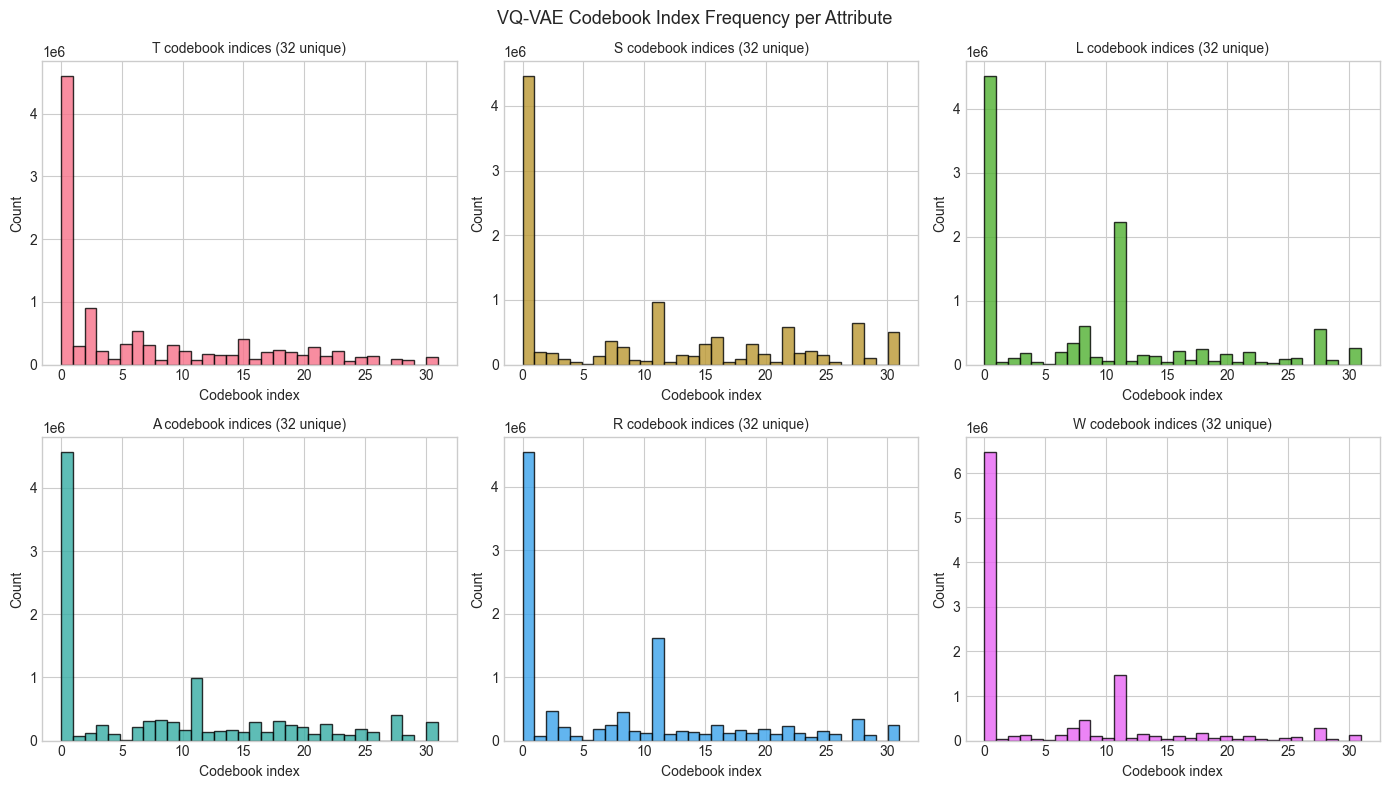

In [121]:
if cb_all is not None:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    
    for i in range(6):
        data = cb_all[i].flatten()
        n_unique = len(np.unique(data))
        axes[i].hist(data, bins=min(n_unique, 64), color=sns.color_palette('husl', 6)[i],
                     edgecolor='black', alpha=0.8)
        axes[i].set_title(f'{attr_names[i]} codebook indices ({n_unique} unique)', fontsize=10)
        axes[i].set_xlabel('Codebook index')
        axes[i].set_ylabel('Count')
    
    plt.suptitle('VQ-VAE Codebook Index Frequency per Attribute', fontsize=13)
    plt.tight_layout()
    plt.show()

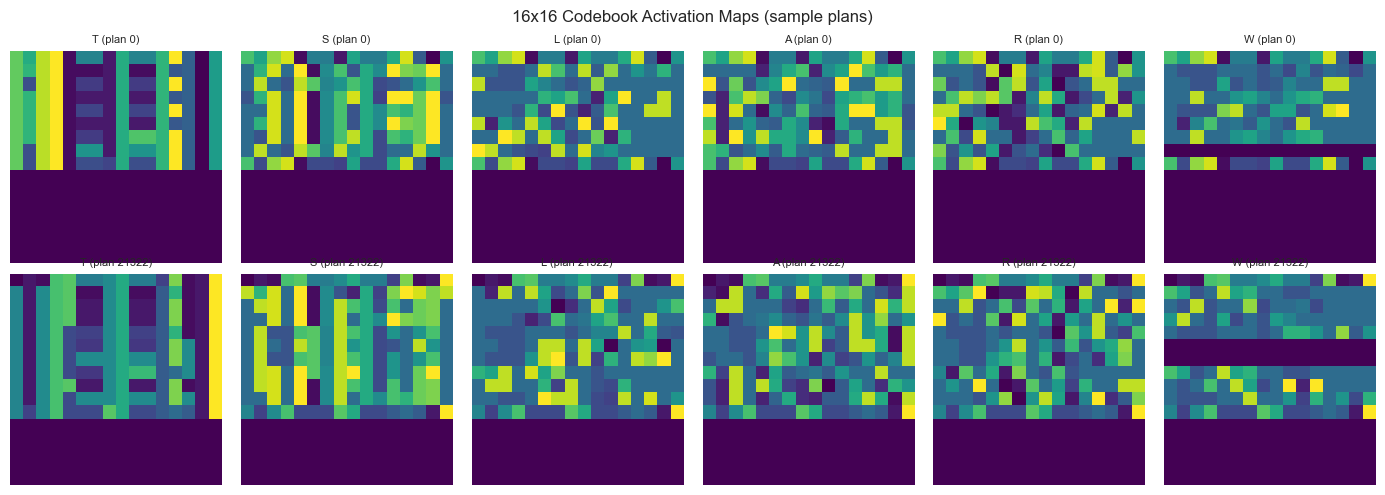

In [122]:
# 16x16 activation heatmap for sample plans
if cb_all is not None:
    fig, axes = plt.subplots(2, 6, figsize=(14, 5))
    sample_plans_cb = [0, N_plans // 2]
    
    for row, pidx in enumerate(sample_plans_cb):
        for col in range(6):
            grid = cb_all[col, pidx]  # (16, 16)
            axes[row, col].imshow(grid, cmap='viridis', aspect='equal')
            axes[row, col].set_title(f'{attr_names[col]} (plan {pidx})', fontsize=8)
            axes[row, col].axis('off')
    
    plt.suptitle('16x16 Codebook Activation Maps (sample plans)', fontsize=12)
    plt.tight_layout()
    plt.show()

=== Site Codebook (from All_codebook_torch.npz) ===
  site                           | shape: (42644, 16)               | dtype: int32      | min:    0.000 | max:   31.000 | mean:   13.009


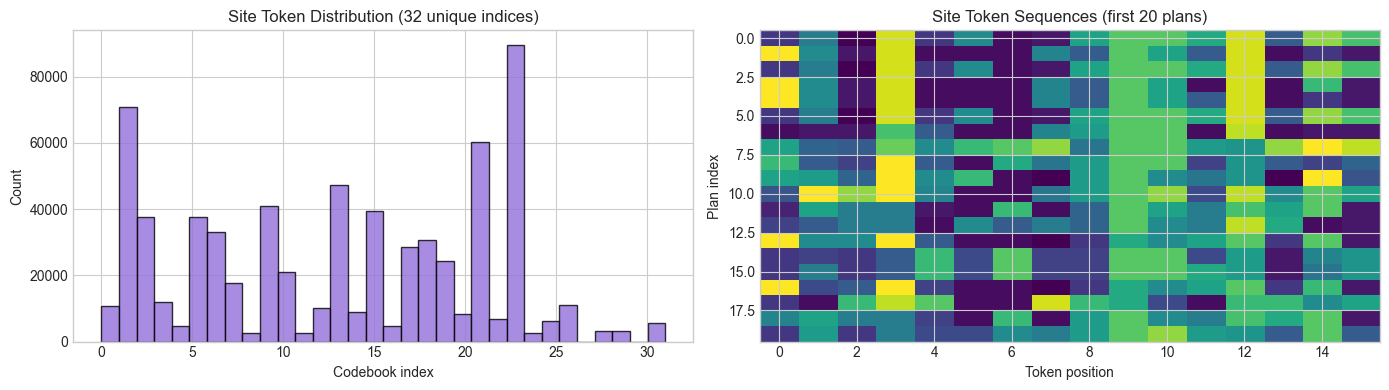


=== Site_codebook.npy (standalone) ===
  Site_codebook                  | shape: (42644, 25)               | dtype: int32      | min:    0.000 | max:   31.000 | mean:   18.164


In [123]:
# Site codebook (from the same npz, key='site')
if cb_site is not None:
    print('=== Site Codebook (from All_codebook_torch.npz) ===')
    print_array_info('site', cb_site)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    n_unique_site = len(np.unique(cb_site))
    axes[0].hist(cb_site.flatten(), bins=min(n_unique_site, 64),
                 color='mediumpurple', edgecolor='black', alpha=0.8)
    axes[0].set_title(f'Site Token Distribution ({n_unique_site} unique indices)')
    axes[0].set_xlabel('Codebook index')
    axes[0].set_ylabel('Count')
    
    # Show a few sample site token sequences
    n_show_site = min(20, cb_site.shape[0])
    axes[1].imshow(cb_site[:n_show_site], cmap='viridis', aspect='auto')
    axes[1].set_title(f'Site Token Sequences (first {n_show_site} plans)')
    axes[1].set_xlabel('Token position')
    axes[1].set_ylabel('Plan index')
    
    plt.tight_layout()
    plt.show()

# Also check standalone Site_codebook.npy
site_cb_path = os.path.join(DATA_DIR, 'Site_codebook.npy')
try:
    site_cb_standalone = np.load(site_cb_path)
    print(f'\n=== Site_codebook.npy (standalone) ===')
    print_array_info('Site_codebook', site_cb_standalone)
except Exception as e:
    print(f'Site_codebook.npy: {e}')

## Section 6: Complete vs Partial Vector Data

The masked training paradigm uses **complete** (all attributes visible) and **partial** (randomly masked) vector representations.

In [124]:
# Load vector mask data
vec_complete_path = os.path.join(DATA_DIR, 'vec_mask_complete_3.npz')
vec_partial_path = os.path.join(DATA_DIR, 'vec_mask_partial_3.npz')

try:
    vec_complete = np.load(vec_complete_path)
    vec_partial = np.load(vec_partial_path)
    
    print('=== vec_mask_complete_3.npz ===')
    for key in vec_complete.keys():
        print_array_info(key, vec_complete[key])
    
    print('\n=== vec_mask_partial_3.npz ===')
    for key in vec_partial.keys():
        print_array_info(key, vec_partial[key])
except Exception as e:
    print(f'Error loading vector mask data: {e}')
    vec_complete = vec_partial = None

=== vec_mask_complete_3.npz ===
  T                              | shape: (127932, 14, 8)           | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.067
  S                              | shape: (127932, 14, 6)           | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.197
  L                              | shape: (127932, 14, 2, 7)        | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.269
  A                              | shape: (127932, 14, 14)          | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.126
  R                              | shape: (127932, 14, 10, 2, 7)    | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.139
  W                              | shape: (127932, 14, 2, 7)        | dtype: uint8      | min:    0.000 | max:    1.000 | mean:    0.165

=== vec_mask_partial_3.npz ===
  T                              | shape: (127932, 14, 8)           | dtype: uint8      | min:    0.000 | max:    

## Section 7: Training Infrastructure

Supporting data for training: valid room counts, batch indices, and train/val split.

=== valid_num.npy ===
  valid_num                      | shape: (127932,)                 | dtype: float64    | min:    0.000 | max:   13.000 | mean:    6.523


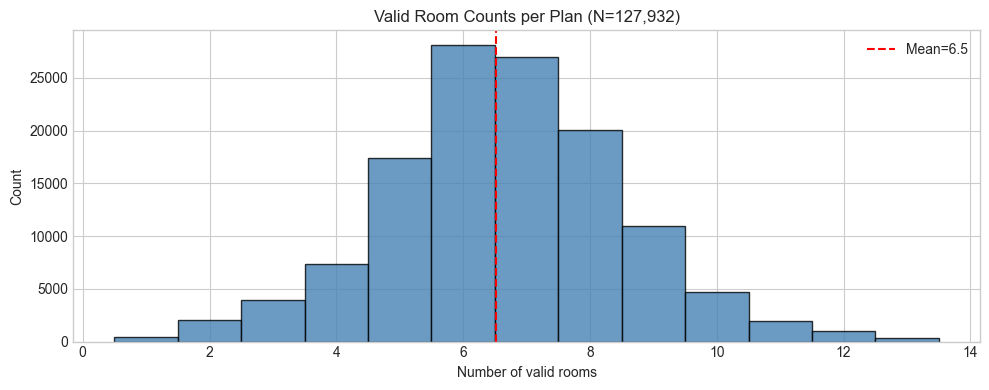

In [126]:
# valid_num.npy - valid room counts per plan
valid_num_path = os.path.join(DATA_DIR, 'valid_num.npy')
try:
    valid_num = np.load(valid_num_path)
    print('=== valid_num.npy ===')
    print_array_info('valid_num', valid_num)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.hist(valid_num, bins=range(1, int(valid_num.max()) + 2),
            color='steelblue', edgecolor='black', alpha=0.8, align='left')
    ax.set_title(f'Valid Room Counts per Plan (N={len(valid_num):,})')
    ax.set_xlabel('Number of valid rooms')
    ax.set_ylabel('Count')
    ax.axvline(valid_num.mean(), color='red', linestyle='--',
               label=f'Mean={valid_num.mean():.1f}')
    ax.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Could not load valid_num.npy: {e}')

=== img_batch_3.npy ===
  img_batch                      | shape: (127932, 16)              | dtype: int32      | min:    0.000 | max: 42643.000 | mean: 1333.352
  Shape interpretation: (127932, 16)


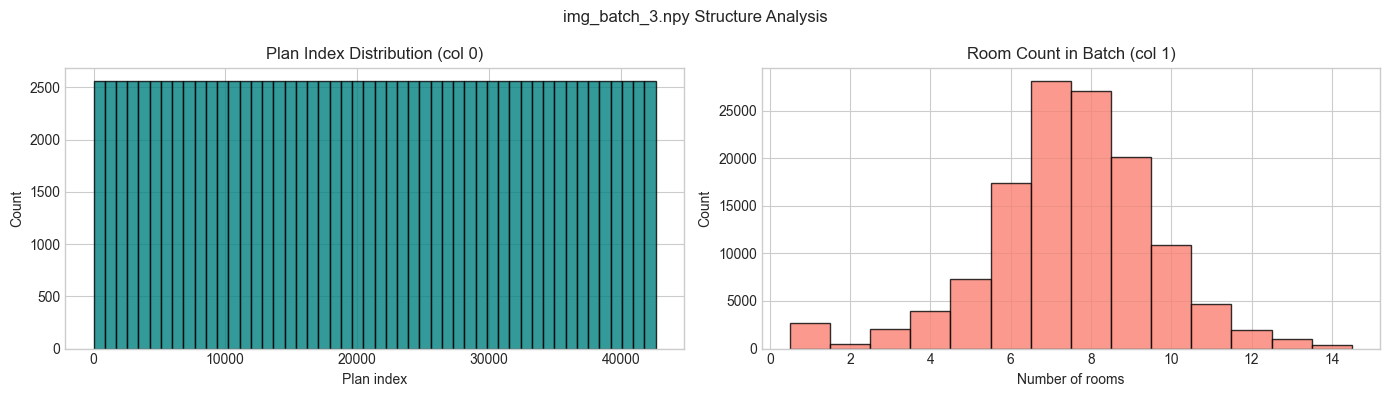


=== Train/Val Split ===
  Total samples (tripled): 127,932
  Training: 86,400 (67.5%)
  Validation: 41,532 (32.5%)


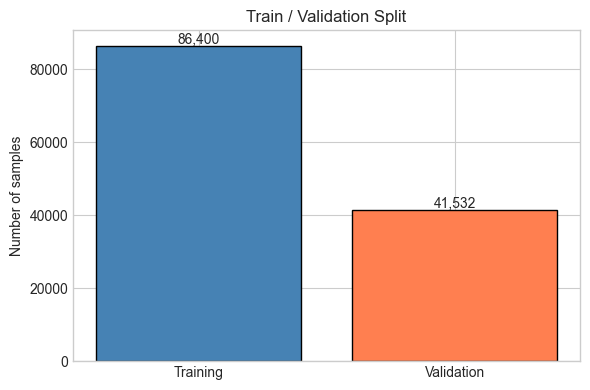

In [127]:
# img_batch_3.npy - batch structure for training
img_batch_path = os.path.join(DATA_DIR, 'img_batch_3.npy')
try:
    img_batch = np.load(img_batch_path)
    print('=== img_batch_3.npy ===')
    print_array_info('img_batch', img_batch)
    print(f'  Shape interpretation: {img_batch.shape}')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Column 0: plan index
    axes[0].hist(img_batch[:, 0], bins=50, color='teal', alpha=0.8, edgecolor='black')
    axes[0].set_title('Plan Index Distribution (col 0)')
    axes[0].set_xlabel('Plan index')
    axes[0].set_ylabel('Count')
    
    # Column 1: room count
    if img_batch.shape[1] > 1:
        axes[1].hist(img_batch[:, 1], bins=range(1, max_room + 2),
                     color='salmon', alpha=0.8, edgecolor='black', align='left')
        axes[1].set_title('Room Count in Batch (col 1)')
        axes[1].set_xlabel('Number of rooms')
        axes[1].set_ylabel('Count')
    
    plt.suptitle('img_batch_3.npy Structure Analysis', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Train/val split
    train_size = 86400
    total = img_batch.shape[0]
    val_size = total - train_size
    print(f'\n=== Train/Val Split ===')
    print(f'  Total samples (tripled): {total:,}')
    print(f'  Training: {train_size:,} ({train_size/total*100:.1f}%)')
    print(f'  Validation: {val_size:,} ({val_size/total*100:.1f}%)')
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(['Training', 'Validation'], [train_size, val_size],
           color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title('Train / Validation Split')
    ax.set_ylabel('Number of samples')
    for i, v in enumerate([train_size, val_size]):
        ax.text(i, v + 500, f'{v:,}', ha='center')
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f'Could not load img_batch_3.npy: {e}')

## Section 8: Sample Floor Plan Reconstruction

Reconstruct complete floor plans from the vector data: decode R vectors to polygons, color by room type, overlay adjacency graph, and show site boundary.

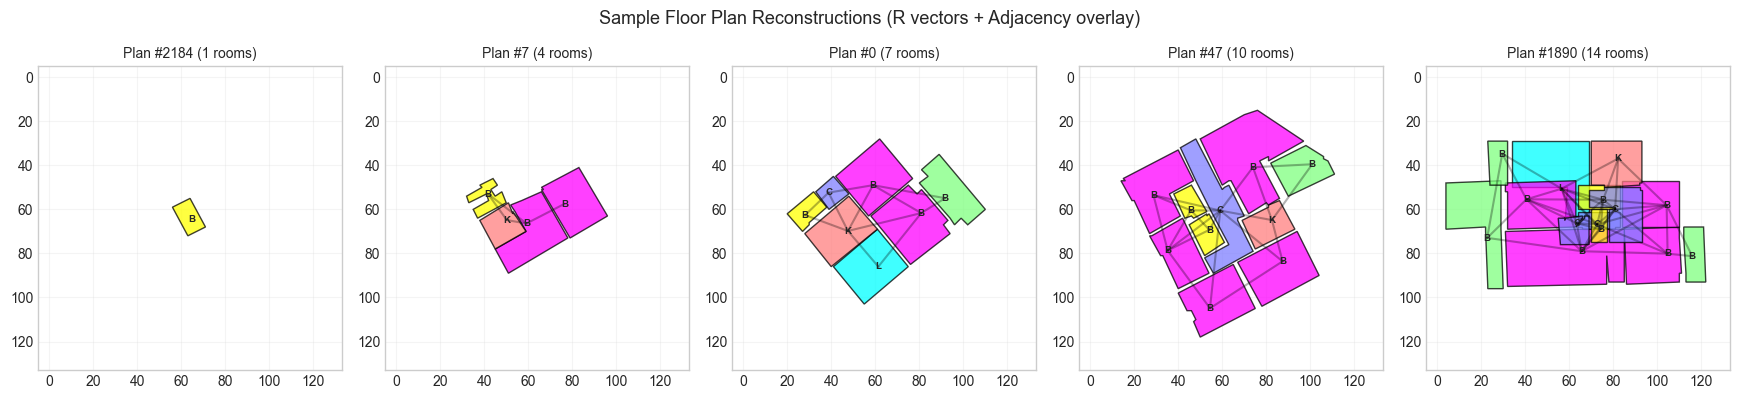

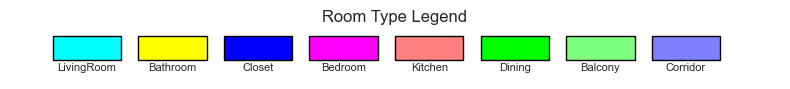


=== bit2int Verification ===
  Decoded coordinate range: [0, 127]
  Expected range: [0, 127] (from 7-bit encoding)
  Valid: True


In [128]:
if R_data is not None and T_data is not None and A_data is not None:
    # Select diverse plans by room count - pick from what actually exists
    unique_counts = sorted(np.unique(rooms_per_plan))
    # Pick ~5 spread across the range
    if len(unique_counts) >= 5:
        pick_indices = np.linspace(0, len(unique_counts) - 1, 5, dtype=int)
        target_counts = [unique_counts[i] for i in pick_indices]
    else:
        target_counts = unique_counts
    
    selected_plans = []
    for tc in target_counts:
        idx = np.where(rooms_per_plan == tc)[0]
        if len(idx) > 0:
            selected_plans.append((tc, idx[0]))
    
    n_show = len(selected_plans)
    fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    
    for ax_i, (n_rooms_target, pidx) in enumerate(selected_plans):
        ax = axes[ax_i]
        n_r = rooms_per_plan[pidx]
        
        # Decode corners
        corners_plan = R_corners[pidx]  # (14, R_num, 2)
        types_plan = T_indices[pidx]    # (14,)
        adj_plan = A_rooms[pidx]        # (14, 14)
        
        room_centers = []
        room_types_plot = []
        
        for r in range(n_r):
            pts = corners_plan[r]
            non_zero = np.any(pts != 0, axis=1)
            pts_valid = pts[non_zero]
            
            if len(pts_valid) >= 3:
                poly = plt.Polygon(pts_valid, closed=True,
                                   facecolor=color_list_rgb[types_plan[r]],
                                   edgecolor='black', linewidth=1.0, alpha=0.75)
                ax.add_patch(poly)
                center = pts_valid.mean(axis=0)
                room_centers.append(center)
                room_types_plot.append(types_plan[r])
                ax.text(center[0], center[1], Types_List[types_plan[r]][0],
                        ha='center', va='center', fontsize=7, fontweight='bold')
            else:
                room_centers.append(None)
                room_types_plot.append(0)
        
        # Overlay adjacency edges
        for i in range(n_r):
            for j in range(i + 1, n_r):
                if adj_plan[i, j] > 0.5 and room_centers[i] is not None and room_centers[j] is not None:
                    ax.plot([room_centers[i][0], room_centers[j][0]],
                            [room_centers[i][1], room_centers[j][1]],
                            'k-', alpha=0.3, linewidth=1.5)
        
        ax.set_xlim(-5, 133)
        ax.set_ylim(-5, 133)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.set_title(f'Plan #{pidx} ({n_r} rooms)', fontsize=10)
        ax.grid(True, alpha=0.2)
    
    plt.suptitle('Sample Floor Plan Reconstructions (R vectors + Adjacency overlay)', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    # Legend
    fig_leg, ax_leg = plt.subplots(figsize=(8, 1))
    for i in range(8):
        ax_leg.add_patch(plt.Rectangle((i, 0), 0.8, 0.8,
                                        facecolor=color_list_rgb[i], edgecolor='black'))
        ax_leg.text(i + 0.4, -0.3, Types_List[i], fontsize=8, ha='center')
    ax_leg.set_xlim(-0.5, 8.5)
    ax_leg.set_ylim(-0.6, 1)
    ax_leg.axis('off')
    ax_leg.set_title('Room Type Legend')
    plt.tight_layout()
    plt.show()
    
    # Verify bit2int produces valid coordinate ranges
    print('\n=== bit2int Verification ===')
    R_all_coords = R_corners[valid_mask]  # all valid room corners
    R_nonzero = R_all_coords[np.any(R_all_coords != 0, axis=(-1,))]
    print(f'  Decoded coordinate range: [{R_nonzero.min()}, {R_nonzero.max()}]')
    print(f'  Expected range: [0, 127] (from {L_dim}-bit encoding)')
    print(f'  Valid: {R_nonzero.min() >= 0 and R_nonzero.max() <= 127}')

## Section 9: Data Pipeline Summary

Overview of the complete data processing pipeline from raw CSV to masked training data.

In [132]:
# ASCII Data Pipeline Flowchart
pipeline = """
================================= DATA PIPELINE =================================

  Raw Swiss Dwelling CSV
        |
        v
  [Data_Process/utils.py]  --->  Polygon Parsing (Shapely)
        |                         - parse_swiss_dewelling_polygon()
        |                         - get_adjacency_graph()
        |                         - make_bit() / bit2int()
        v
  [Extract_SwissD_Data.ipynb]  --->  swissD_Dual_Modal.npz
        |                             (T, S, L, A, R, W vectors)
        |                             42,644 plans x 6 attributes
        |
        +----> Vector Branch           Image Branch <----+
        |      (direct encoding)       (128x128 renders) |
        v                              v                 |
  vec_mask_complete_3.npz       [Pretrain_VQVAE/]        |
  vec_mask_partial_3.npz         VQ-VAE Training         |
        |                              |                 |
        |                              v                 |
        |                   All_codebook_torch.npz       |
        |                   Site_codebook.npy             |
        |                              |                 |
        |                              v                 |
        |                   img_mask_complete_3.npz       |
        |                   img_mask_partial_3.npz        |
        |                              |                 |
        +------->  Masked Dual-Modal Training  <---------+
                   (MaskLayout Transformer)
                   Train: 86,400 | Val: remaining
                   (original 42,644 x3 = 127,932)

=================================================================================
"""
print(pipeline)


================================= DATA PIPELINE =================================

  Raw Swiss Dwelling CSV
        |
        v
  [Data_Process/utils.py]  --->  Polygon Parsing (Shapely)
        |                         - parse_swiss_dewelling_polygon()
        |                         - get_adjacency_graph()
        |                         - make_bit() / bit2int()
        v
  [Extract_SwissD_Data.ipynb]  --->  swissD_Dual_Modal.npz
        |                             (T, S, L, A, R, W vectors)
        |                             42,644 plans x 6 attributes
        |
        +----> Vector Branch           Image Branch <----+
        |      (direct encoding)       (128x128 renders) |
        v                              v                 |
  vec_mask_complete_3.npz       [Pretrain_VQVAE/]        |
  vec_mask_partial_3.npz         VQ-VAE Training         |
        |                              |                 |
        |                              v                 |
    

In [133]:
# Summary Statistics Table
print('=== Dataset Summary Statistics ===')
summary_data = []

files_info = [
    ('swissD_Dual_Modal.npz', 'Data/sqe/', 'Base vector data (T,S,L,A,R,W)'),
    ('new_R_10.npy', 'Data/sqe/', 'Room polygons (10-corner version)'),
    ('All_codebook_torch.npz', 'Data/', 'VQ-VAE codebook indices (6 attrs)'),
    ('Site_codebook.npy', 'Data/', 'Site boundary codebook tokens'),
    ('img_mask_complete_3.npz', 'Data/', 'Complete image tokens'),
    ('img_mask_partial_3.npz', 'Data/', 'Partial (masked) image tokens'),
    ('vec_mask_complete_3.npz', 'Data/', 'Complete vector attributes'),
    ('vec_mask_partial_3.npz', 'Data/', 'Partial (masked) vector attributes'),
    ('valid_num.npy', 'Data/', 'Valid room counts per plan'),
    ('img_batch_3.npy', 'Data/', 'Training batch indices'),
    ('room_type.csv', 'Data_Process/', 'Room type taxonomy (74 types)'),
]

for fname, fdir, desc in files_info:
    fpath = os.path.join(MASKLAYOUT_DIR, fdir, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        summary_data.append([fname, fdir, f'{size_mb:.1f} MB', desc])
    else:
        summary_data.append([fname, fdir, 'Not found', desc])

df_summary = pd.DataFrame(summary_data, columns=['File', 'Directory', 'Size', 'Description'])
display(df_summary)

print('\n=== Key Dimensions ===')
dims = [
    ('max_room', max_room, 'Maximum rooms per plan'),
    ('T_dim', T_dim, 'Type one-hot dimension'),
    ('L_dim', L_dim, 'Location bits (max 128)'),
    ('S_dim', S_dim, 'Size/area bits (max 64)'),
    ('R_num', R_num_20, 'Max corner points per room'),
    ('img_res', img_res, 'Image resolution'),
]
for name, val, desc in dims:
    print(f'  {name:12s} = {val:5d}  ({desc})')

=== Dataset Summary Statistics ===


,File,Directory,Size,Description
0,swissD_Dual_Modal.npz,Data/sqe/,10.5 MB,"Base vector data (T,S,L,A,R,W)"
1,new_R_10.npy,Data/sqe/,91.1 MB,Room polygons (10-corner version)
2,All_codebook_torch.npz,Data/,14.2 MB,VQ-VAE codebook indices (6 attrs)
3,Site_codebook.npy,Data/,4.1 MB,Site boundary codebook tokens
4,img_mask_complete_3.npz,Data/,20.2 MB,Complete image tokens
5,img_mask_partial_3.npz,Data/,8.9 MB,Partial (masked) image tokens
6,vec_mask_complete_3.npz,Data/,19.8 MB,Complete vector attributes
7,vec_mask_partial_3.npz,Data/,9.9 MB,Partial (masked) vector attributes
8,valid_num.npy,Data/,1.0 MB,Valid room counts per plan
9,img_batch_3.npy,Data/,7.8 MB,Training batch indices



=== Key Dimensions ===
  max_room     =    14  (Maximum rooms per plan)
  T_dim        =    10  (Type one-hot dimension)
  L_dim        =     7  (Location bits (max 128))
  S_dim        =     6  (Size/area bits (max 64))
  R_num        =    20  (Max corner points per room)
  img_res      =   128  (Image resolution)
